In [1]:
!wget https://drive.google.com/uc?id=1dhh4m9VRLUSmbaHfge2iRSW5Azkpefco  -O kitty3.png
!wget https://drive.google.com/uc?id=1o0UMPTyUFzX9CaQp-BwYXgkCho1Zo6yL  -O kitty55.png
!wget https://drive.google.com/uc?id=1Jk0cEtQt4HxkLcKlmTHukpb22gJZ4dmL -O noisy_kitty55.png
!wget https://drive.google.com/uc?id=1xCNA5338nzj1GgGQ5-oBA1dKCW1Mvn21 -O hillbefore_noise10%.jpg


--2025-11-16 10:53:50--  https://drive.google.com/uc?id=1dhh4m9VRLUSmbaHfge2iRSW5Azkpefco
Resolving drive.google.com (drive.google.com)... 74.125.68.139, 74.125.68.138, 74.125.68.100, ...
Connecting to drive.google.com (drive.google.com)|74.125.68.139|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1dhh4m9VRLUSmbaHfge2iRSW5Azkpefco [following]
--2025-11-16 10:53:50--  https://drive.usercontent.google.com/download?id=1dhh4m9VRLUSmbaHfge2iRSW5Azkpefco
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 172.217.70.132, 2404:6800:4003:c20::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|172.217.70.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1194851 (1.1M) [image/png]
Saving to: ‘kitty3.png’

kitty3.png          100%[===================>]   1.14M  --.-KB/s    in 0.03s   

2025-11-16 10:53:52 (38.5 MB/s) - ‘kitty3.png’ saved [

In [2]:
import cv2
img = cv2.imread('kitty3.png')
print(img.shape)
img = cv2.imread('kitty55.png')
print(img.shape)
img = cv2.imread('noisy_kitty55.png')
print(img.shape)


(1000, 1000, 3)
(500, 500, 3)
(500, 500, 3)


# L10 Object Recognition Part I

In [3]:
import matplotlib.pyplot as plt
from skimage.feature import hog
from skimage import data, exposure
import cv2
import numpy as np

## Histogram of Oriented Gradient (HOG)

* simple image

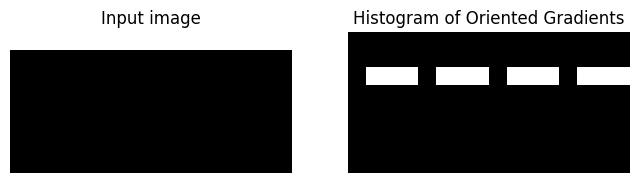

In [4]:
image = np.array([[1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1],[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0]
                  ,[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0]
                  ,[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0]
                  ,[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0]
                  ,[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0]])

fd, hog_image = hog(image, orientations=5, pixels_per_cell=(4, 4), cells_per_block=(2, 2), visualize=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4), sharex=True, sharey=True)

ax1.axis('off')
ax1.imshow(image, cmap=plt.cm.gray)
ax1.set_title('Input image')


ax2.axis('off')
ax2.imshow(hog_image, cmap=plt.cm.gray)
ax2.set_title('Histogram of Oriented Gradients')
plt.show()

In [5]:
  print(fd.shape)

(60,)


* Astronaut image

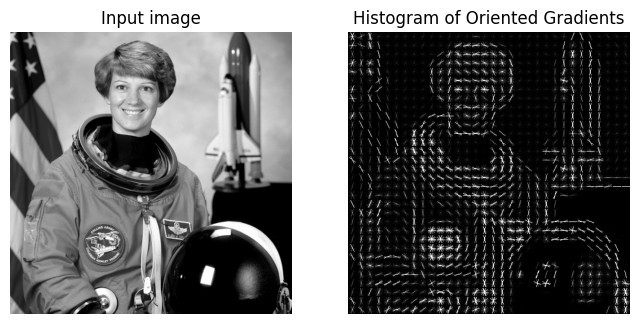

In [6]:
image = data.astronaut()
image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)


# TO DO : Select different orientaion, pixels_per_cell and cells_per_block and analyze the results
fd, hog_image = hog(image, orientations=9, pixels_per_cell=(16, 16), cells_per_block=(2, 2), visualize=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4), sharex=True, sharey=True)

ax1.axis('off')
ax1.imshow(image, cmap=plt.cm.gray)
ax1.set_title('Input image')

# Rescale histogram for better display
hog_image_rescaled = exposure.rescale_intensity(hog_image, in_range=(0, 10))

ax2.axis('off')
ax2.imshow(hog_image_rescaled, cmap=plt.cm.gray)
ax2.set_title('Histogram of Oriented Gradients')
plt.show()



## HOG + Neural Networks



* MNIST dataset

In [7]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report
from skimage.feature import hog
from keras.datasets import mnist

# ----------------------------
# 1. Load MNIST dataset
# ----------------------------
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# ----------------------------
# 2. Split train / validation / test sets
# ----------------------------
x_train, x_val, y_train, y_val = train_test_split(
    x_train, y_train, test_size=0.2, random_state=42
)

# ----------------------------
# 3. Preprocessing
# ----------------------------
# Normalize pixel values to [0, 1]
x_train = x_train / 255.0
x_val = x_val / 255.0
x_test = x_test / 255.0

# ----------------------------
# 4. Compute HOG features
# ----------------------------
def extract_hog_features(images):
    features = []
    for img in images:
        hog_feature = hog(
            img,
            orientations=9,
            pixels_per_cell=(7, 7),
            cells_per_block=(2, 2)
        )
        features.append(hog_feature)
    return np.array(features)

print("Computing HOG features ...")
X_train_hog = extract_hog_features(x_train)
X_val_hog   = extract_hog_features(x_val)
X_test_hog  = extract_hog_features(x_test)

print("HOG feature shape:", X_train_hog.shape)

# ----------------------------
# 5. Build Neural Network model
# ----------------------------
model = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    solver='adam',
    batch_size=128,
    max_iter=20,
    random_state=42,
    verbose = 1
)

# ----------------------------
# 6. Train the model
# ----------------------------
print("Training Neural Network ...")
model.fit(X_train_hog, y_train)

# ----------------------------
# 7. Evaluate performance
# ----------------------------
y_pred_val = model.predict(X_val_hog)
y_pred_test = model.predict(X_test_hog)

print("Validation accuracy:", accuracy_score(y_val, y_pred_val))
print("Test accuracy:", accuracy_score(y_test, y_pred_test))
print("\nClassification Report (Test):\n", classification_report(y_test, y_pred_test))


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Computing HOG features ...
HOG feature shape: (48000, 324)
Training Neural Network ...
Iteration 1, loss = 0.39965454
Iteration 2, loss = 0.13205272
Iteration 3, loss = 0.10939313
Iteration 4, loss = 0.09458296
Iteration 5, loss = 0.08354383
Iteration 6, loss = 0.07584269
Iteration 7, loss = 0.06858298
Iteration 8, loss = 0.06354502
Iteration 9, loss = 0.05883747
Iteration 10, loss = 0.05294656
Iteration 11, loss = 0.04910805
Iteration 12, loss = 0.04470576
Iteration 13, loss = 0.04213044
Iteration 14, loss = 0.04005390
Iteration 15, loss = 0.03596592
Iteration 16, loss = 0.03377508
Iteration 17, loss = 0.03133425
Iteration 18, loss = 0.02915637
Iteration 19, loss = 0.02724999
Iteration 20, loss = 0.02469732
Validation accuracy: 0.9773333333333334
Test accuracy: 0.9767

Classification Report (Test):
               precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99     

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


* Inferencing

[9]


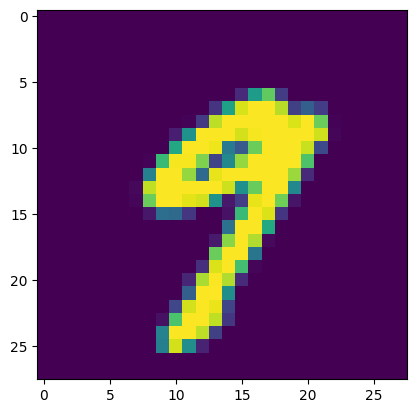

In [8]:
fd_test = hog(x_test[20].reshape((28,28))/255.0, orientations=9, pixels_per_cell=(7,7),cells_per_block=(2,2))
print(model.predict(fd_test.reshape(1,324)))

plt.imshow(x_test[20])
plt.show()

In [9]:
fd_test.shape

(324,)

## Convolutional Neural Networks (CNN)



In [10]:
import torch
from torch import nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets
from torchvision.transforms import ToTensor
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torchsummary import summary

### Prep data

In [11]:
train_data = datasets.MNIST(
    root = 'data',
    train = True,
    transform = ToTensor(),
    download = True,
)
test_data = datasets.MNIST(
    root = 'data',
    train = False,
    transform = ToTensor()
)

train_data, val_data = random_split(train_data,[50000,10000])


batch_size = 64

# Create data loaders.
train_dataloader = DataLoader(train_data, batch_size=batch_size)
val_dataloader = DataLoader(val_data, batch_size=batch_size)
test_dataloader = DataLoader(test_data, batch_size=batch_size)

for X, y in train_dataloader:
    print(f"Shape of X [N, C, H, W]: {X.shape}")
    print(f"Shape of y: {y.shape} {y.dtype}")
    break

for X, y in val_dataloader:
    print(f"Shape of X [N, C, H, W]: {X.shape}")
    print(f"Shape of y: {y.shape} {y.dtype}")
    break

for X, y in test_dataloader:
    print(f"Shape of X [N, C, H, W]: {X.shape}")
    print(f"Shape of y: {y.shape} {y.dtype}")
    break



100%|██████████| 9.91M/9.91M [00:02<00:00, 4.45MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 130kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.23MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.28MB/s]

Shape of X [N, C, H, W]: torch.Size([64, 1, 28, 28])
Shape of y: torch.Size([64]) torch.int64
Shape of X [N, C, H, W]: torch.Size([64, 1, 28, 28])
Shape of y: torch.Size([64]) torch.int64
Shape of X [N, C, H, W]: torch.Size([64, 1, 28, 28])
Shape of y: torch.Size([64]) torch.int64


In [12]:
print((5*5*1+1)*16)

416


### Prep model

In [13]:
# Creating Models
# Get cpu or gpu device for training.
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device")

import torch.nn.functional as F
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(
                in_channels=1,
                out_channels=16,
                kernel_size=5,
                stride=1,
                padding=2,
            ),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(16, 32, 5, 1, 2),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        # fully connected layer, output 10 classes
        self.out = nn.Linear(32 * 7 * 7, 10)
    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)

        # flatten the output of conv2 to (batch_size, 32 * 7 * 7)
        x = x.view(x.size(0), -1)
        output = F.log_softmax(self.out(x), dim=1)
        return output




model = Net().to(device)
print(model)

summary(model, input_size=(1, 28, 28))

# Optimizing the Model Parameters
loss_fn = nn.CrossEntropyLoss()
# optimizer = torch.optim.SGD(model.parameters(), lr=1e-3)
optimizer = torch.optim.Adam(model.parameters(), lr = 0.01)




Using cuda device
Net(
  (conv1): Sequential(
    (0): Conv2d(1, 16, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (out): Linear(in_features=1568, out_features=10, bias=True)
)
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 16, 28, 28]             416
       BatchNorm2d-2           [-1, 16, 28, 28]              32
              ReLU-3           [-1, 16, 28, 28]               0
         MaxPool2d-4           [-1, 16, 14, 14]               0
            Conv2d-5           [-1, 

In [14]:
print((5*5*1 + 1)*16)

416


In [15]:
print((5*5*1 + 1)*16)
print((5*5*16 + 1)*32)
print((7*7*32+1)*10)
print()

416
12832
15690



### Training

In [16]:
def train(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        # Compute prediction error
        pred = model(X)

        # print(type(pred),type(y))
        loss = loss_fn(pred, y)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if batch % 100 == 0:
            loss, current = loss.item(), batch * len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")



def test(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    test_loss /= num_batches
    correct /= size
    print(f"Test Accuracy: {(100*correct):>0.1f}%,  Avg loss: {test_loss:>8f} \n")

def val(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    test_loss /= num_batches
    correct /= size
    print(f"Val Accuracy: {(100*correct):>0.1f}%,  Avg loss: {test_loss:>8f} \n")

epochs = 5
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train(train_dataloader, model, loss_fn, optimizer)
    val(val_dataloader, model, loss_fn)
print("Done!")


Epoch 1
-------------------------------
loss: 2.311685  [    0/50000]
loss: 2.293317  [ 6400/50000]
loss: 2.306118  [12800/50000]
loss: 2.298759  [19200/50000]
loss: 2.315701  [25600/50000]
loss: 2.300462  [32000/50000]
loss: 2.291320  [38400/50000]
loss: 2.296227  [44800/50000]
Val Accuracy: 11.0%,  Avg loss: 2.302609 

Epoch 2
-------------------------------
loss: 2.301147  [    0/50000]
loss: 2.293632  [ 6400/50000]
loss: 2.306262  [12800/50000]
loss: 2.298832  [19200/50000]
loss: 2.315662  [25600/50000]
loss: 2.300383  [32000/50000]
loss: 2.291286  [38400/50000]
loss: 2.296272  [44800/50000]
Val Accuracy: 11.0%,  Avg loss: 2.302636 

Epoch 3
-------------------------------
loss: 2.300989  [    0/50000]
loss: 2.293610  [ 6400/50000]
loss: 2.306319  [12800/50000]
loss: 2.298829  [19200/50000]
loss: 2.315659  [25600/50000]
loss: 2.300366  [32000/50000]
loss: 2.291277  [38400/50000]
loss: 2.296285  [44800/50000]
Val Accuracy: 11.0%,  Avg loss: 2.302644 

Epoch 4
-----------------------

### Inferencing

In [17]:
torch.save(model.state_dict(), "model.pth")
print("Saved PyTorch Model State to model.pth")

_model = Net().to(device)
weights=torch.load("model.pth")
_model.load_state_dict(weights)

print("Test accuracy")
test(test_dataloader, _model, loss_fn)



Saved PyTorch Model State to model.pth
Test accuracy
Test Accuracy: 11.3%,  Avg loss: 2.301089 



# L11 Object Recognition II

### visualizing filters

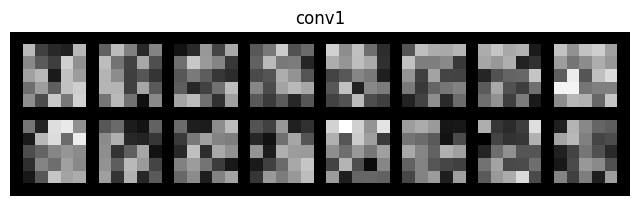

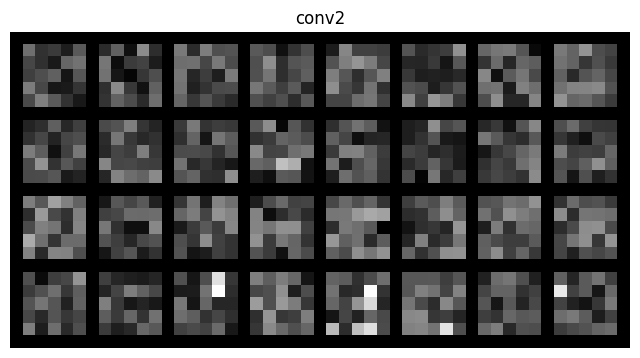

In [18]:
from torchvision import utils

def visTensor(tensor, ch=0, allkernels=False, nrow=8, padding=1):
    n,c,w,h = tensor.shape

    if allkernels: tensor = tensor.view(n*c, -1, w, h)
    elif c != 3: tensor = tensor[:,ch,:,:].unsqueeze(dim=1)

    # rows = np.min((tensor.shape[0] // nrow + 1, 64))
    rows = tensor.shape[0] // nrow + 1
    grid = utils.make_grid(tensor, nrow=nrow, normalize=True, padding=padding)
    plt.figure( figsize=(nrow,rows) )
    plt.imshow(grid.detach().cpu().numpy().transpose((1, 2, 0)))





filter = model.conv1[0].weight.data.clone()
visTensor(filter, ch=0, allkernels=False)

plt.axis('off')
plt.title("conv1")
plt.ioff()
plt.show()


layer = 0
filter = model.conv2[0].weight.data.clone()
visTensor(filter, ch=0, allkernels=False)

plt.axis('off')
plt.ioff()
plt.title("conv2")
plt.show()

### visualizing feature maps

In [19]:
summary(model, input_size=(1, 28, 28))
print(model)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 16, 28, 28]             416
       BatchNorm2d-2           [-1, 16, 28, 28]              32
              ReLU-3           [-1, 16, 28, 28]               0
         MaxPool2d-4           [-1, 16, 14, 14]               0
            Conv2d-5           [-1, 32, 14, 14]          12,832
              ReLU-6           [-1, 32, 14, 14]               0
         MaxPool2d-7             [-1, 32, 7, 7]               0
            Linear-8                   [-1, 10]          15,690
Total params: 28,970
Trainable params: 28,970
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.42
Params size (MB): 0.11
Estimated Total Size (MB): 0.53
----------------------------------------------------------------
Net(
  (conv1): Sequential(
    (0): Conv2d(

Total convolution layers: 2
torch.Size([1, 28, 28])
Predicted: "1", Actual: "9"
tensor([[-2.3528, -2.1888, -2.2412, -2.2691, -2.3150, -2.4132, -2.3348, -2.3150,
         -2.3082, -2.3048]], device='cuda:0')


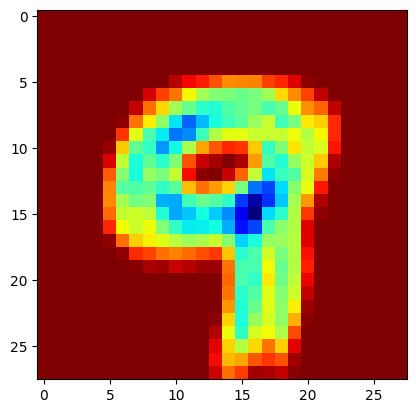

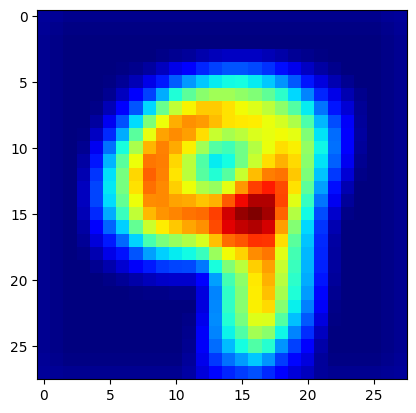

<Figure size 640x480 with 0 Axes>

In [20]:
# we will save the conv layer weights in this list
model_weights =[]
conv_layers = []
# get all the model children as list
model_children = list(model.children())
# counter to keep count of the conv layers
counter = 0
# append all the conv layers and their respective wights to the list
for i in range(len(model_children)):
    if type(model_children[i]) == nn.Conv2d:
        counter+=1
        model_weights.append(model_children[i].weight)
        conv_layers.append(model_children[i])
    elif type(model_children[i]) == nn.Sequential:
        for j in range(len(model_children[i])):
            if type(model_children[i][j]) == nn.Conv2d:
                counter+=1
                model_weights.append(model_children[i][j].weight)
                conv_layers.append(model_children[i][j])
print(f"Total convolution layers: {counter}")


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

# Set model to eval
model.eval()

# Get prediction
X, y = test_data[105][0], test_data[105][1]
print(X.shape)
with torch.no_grad():
    output = model(X.unsqueeze(0).to(device))
    predicted, actual = output[0].argmax(0), y
    print(f'Predicted: "{predicted}", Actual: "{actual}"')

print(output)



outputs = []
names = []
image = X.unsqueeze(0).to(device)
for layer in conv_layers[0:]:
    image = layer(image)
    outputs.append(image)
    names.append(str(layer))

processed = []
for feature_map in outputs:
    feature_map = feature_map.squeeze(0)
    gray_scale = torch.sum(feature_map,0)
    gray_scale = gray_scale / feature_map.shape[0]
    processed.append(gray_scale.data.cpu().numpy())



for i in range(len(processed)):
    plt.imshow(processed[i],cmap='jet')
    plt.show()
plt.savefig(str('feature_maps.jpg'), bbox_inches='tight')
plt.show()



## Exercise #1 Augmentation

In [21]:
!wget https://drive.google.com/uc?id=1Yox-XWM-PY9vFtDdzB_y_U3SK2paewwe -O kitty.jpg

--2025-11-16 10:56:06--  https://drive.google.com/uc?id=1Yox-XWM-PY9vFtDdzB_y_U3SK2paewwe
Resolving drive.google.com (drive.google.com)... 74.125.68.139, 74.125.68.138, 74.125.68.100, ...
Connecting to drive.google.com (drive.google.com)|74.125.68.139|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1Yox-XWM-PY9vFtDdzB_y_U3SK2paewwe [following]
--2025-11-16 10:56:06--  https://drive.usercontent.google.com/download?id=1Yox-XWM-PY9vFtDdzB_y_U3SK2paewwe
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 172.217.70.132, 2404:6800:4003:c20::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|172.217.70.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 79570 (78K) [image/jpeg]
Saving to: ‘kitty.jpg’

kitty.jpg           100%[===================>]  77.71K  --.-KB/s    in 0s      

2025-11-16 10:56:07 (152 MB/s) - ‘kitty.jpg’ saved [79570

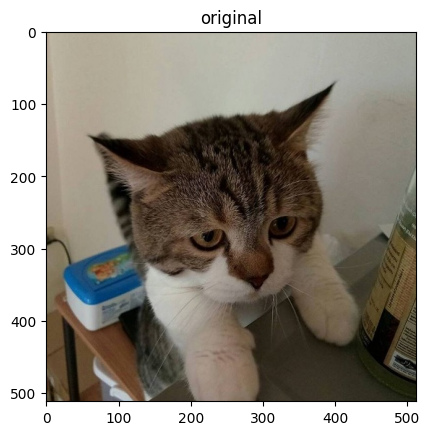

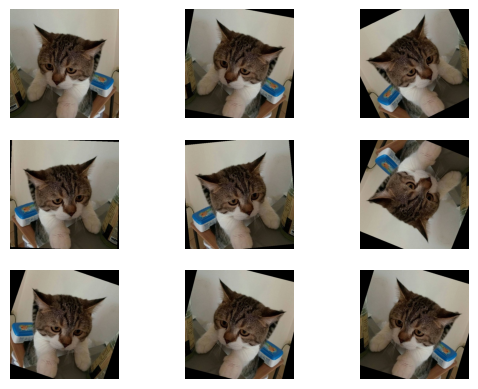

In [22]:
from torchvision import transforms

# define transformations
data_transform = transforms.Compose([
        transforms.RandomHorizontalFlip(0.3),
        transforms.RandomVerticalFlip(0.3),
        transforms.RandomRotation((-30,30)),
        transforms.ToTensor(),
])

from PIL import Image
import numpy as np
im = Image.open("kitty.jpg")

plt.imshow(im)
plt.title("original")
plt.show()

for i in range(1,10):
  img_tr=data_transform(im).numpy()
  plt.subplot(3,3,i)
  plt.imshow(img_tr.transpose(1,2,0));
  plt.axis('off')
plt.show()

### Augmentation with MNIST dataset

In [23]:
# define transformations
data_transform = transforms.Compose([
        transforms.RandomHorizontalFlip(0.3),
        transforms.RandomVerticalFlip(0.3),
        transforms.RandomRotation((-30,30)),
        transforms.ToTensor(),
])

train_data = datasets.MNIST(
    root = 'data',
    train = True,
    # transform = ToTensor(),
    transform = data_transform,
    download = True,
)
test_data = datasets.MNIST(
    root = 'data',
    train = False,
    transform = ToTensor()
)

train_data, val_data = random_split(train_data,[50000,10000])


batch_size = 64

# Create data loaders.
train_dataloader = DataLoader(train_data, batch_size=batch_size)
val_dataloader = DataLoader(val_data, batch_size=batch_size)
test_dataloader = DataLoader(test_data, batch_size=batch_size)

for X, y in train_dataloader:
    print(f"Shape of X [N, C, H, W]: {X.shape}")
    print(f"Shape of y: {y.shape} {y.dtype}")
    break

for X, y in val_dataloader:
    print(f"Shape of X [N, C, H, W]: {X.shape}")
    print(f"Shape of y: {y.shape} {y.dtype}")
    break

for X, y in test_dataloader:
    print(f"Shape of X [N, C, H, W]: {X.shape}")
    print(f"Shape of y: {y.shape} {y.dtype}")
    break


# Creating Models
# Get cpu or gpu device for training.
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device")

import torch.nn.functional as F
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(
                in_channels=1,
                out_channels=16,
                kernel_size=5,
                stride=1,
                padding=2,
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(16, 32, 5, 1, 2),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        # fully connected layer, output 10 classes
        self.out = nn.Linear(32 * 7 * 7, 10)
    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)

        # flatten the output of conv2 to (batch_size, 32 * 7 * 7)
        x = x.view(x.size(0), -1)
        output = F.log_softmax(self.out(x), dim=1)
        return output




model = Net().to(device)
print(model)

summary(model, input_size=(1, 28, 28))

# Optimizing the Model Parameters
loss_fn = nn.CrossEntropyLoss()
# optimizer = torch.optim.SGD(model.parameters(), lr=1e-3)
optimizer = torch.optim.Adam(model.parameters(), lr = 0.01)


def train(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        # Compute prediction error
        pred = model(X)

        # print(type(pred),type(y))
        loss = loss_fn(pred, y)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if batch % 100 == 0:
            loss, current = loss.item(), batch * len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")



def test(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    test_loss /= num_batches
    correct /= size
    print(f"Test Accuracy: {(100*correct):>0.1f}%,  Avg loss: {test_loss:>8f} \n")

def val(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    test_loss /= num_batches
    correct /= size
    print(f"Val Accuracy: {(100*correct):>0.1f}%,  Avg loss: {test_loss:>8f} \n")

epochs = 5
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train(train_dataloader, model, loss_fn, optimizer)
    val(val_dataloader, model, loss_fn)
print("Done!")



torch.save(model.state_dict(), "model.pth")
print("Saved PyTorch Model State to model.pth")

_model = Net().to(device)
weights=torch.load("model.pth")
_model.load_state_dict(weights)

print("Test accuracy")
test(test_dataloader, _model, loss_fn)


Shape of X [N, C, H, W]: torch.Size([64, 1, 28, 28])
Shape of y: torch.Size([64]) torch.int64
Shape of X [N, C, H, W]: torch.Size([64, 1, 28, 28])
Shape of y: torch.Size([64]) torch.int64
Shape of X [N, C, H, W]: torch.Size([64, 1, 28, 28])
Shape of y: torch.Size([64]) torch.int64
Using cuda device
Net(
  (conv1): Sequential(
    (0): Conv2d(1, 16, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (out): Linear(in_features=1568, out_features=10, bias=True)
)
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 16, 28, 28]             416
              ReLU-2           [-1,

## Vision transformer


In [24]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

In [25]:
# 1. Multi-Head Self-Attention
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, dim, num_heads=4): # 4 heads
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = dim // num_heads
        self.scale = self.head_dim ** -0.5
        self.qkv = nn.Linear(dim, dim * 3)
        self.proj = nn.Linear(dim, dim)

    def forward(self, x):
        B, N, D = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, self.head_dim)
        q, k, v = qkv[:, :, 0], qkv[:, :, 1], qkv[:, :, 2]
        q, k, v = q.transpose(1, 2), k.transpose(1, 2), v.transpose(1, 2)
        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = F.softmax(attn, dim=-1)
        out = (attn @ v).transpose(1, 2).reshape(B, N, D)
        return self.proj(out)

# 2. Transformer Encoder Block
class TransformerEncoder(nn.Module):
    def __init__(self, dim, num_heads=4, mlp_ratio=4):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = MultiHeadSelfAttention(dim, num_heads)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = nn.Sequential(
            nn.Linear(dim, dim * mlp_ratio),
            nn.GELU(),
            nn.Linear(dim * mlp_ratio, dim)
        )

    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x

# 3. Sin–Cos 2D Positional Encoding
class PositionalEncoding2D(nn.Module):
    def __init__(self, num_patches, dim):
        super().__init__()
        grid_size = int(math.sqrt(num_patches))
        assert grid_size ** 2 == num_patches, "num_patches must form a square grid"
        self.register_buffer("pos_embed", self.build_2d_sincos(dim, grid_size))

    def build_2d_sincos(self, dim, grid):
        assert dim % 2 == 0, "embedding dim must be divisible by 2"
        dim_half = dim // 2
        grid_y, grid_x = torch.meshgrid(
            torch.arange(grid, dtype=torch.float32),
            torch.arange(grid, dtype=torch.float32),
            indexing="ij"
        )
        pos_x = self.get_1d_sincos(grid_x.flatten(), dim_half)
        pos_y = self.get_1d_sincos(grid_y.flatten(), dim_half)
        pos = torch.cat([pos_x, pos_y], dim=1)
        return pos.unsqueeze(0)  # shape (1, num_patches, dim)

    def get_1d_sincos(self, pos, dim):
        omega = torch.arange(dim // 2, dtype=torch.float32) / (dim / 2)
        omega = 1. / (10000 ** omega)
        out = pos[:, None] * omega[None, :]
        sin, cos = torch.sin(out), torch.cos(out)
        return torch.cat([sin, cos], dim=1)

    def forward(self, x):
        return x + self.pos_embed.to(x.device)

# 3. Alternate Position Encoding using Learnable Paramters
# class PositionalEncoding2D(nn.Module):
#     def __init__(self, num_patches, dim):
#         super().__init__()
#         self.pos_embed = nn.Parameter(torch.randn(1, num_patches, dim))

#     def forward(self, x):
#         return x + self.pos_embed


# 4. Vision Transformer (Mini)
class MiniViT(nn.Module):
    def __init__(self, img_size=28, patch_size=7, dim=64, depth=2, num_heads=4, num_classes=10):
        super().__init__()
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2
        patch_dim = patch_size * patch_size  # grayscale
        self.patch_embed = nn.Linear(patch_dim, dim)

        # Class token
        self.class_token = nn.Parameter(torch.zeros(1, 1, dim))
        self.pos_embed = PositionalEncoding2D(self.num_patches, dim)

        self.blocks = nn.ModuleList([TransformerEncoder(dim, num_heads) for _ in range(depth)]) # depth = l,
        self.norm = nn.LayerNorm(dim)
        self.head = nn.Linear(dim, num_classes)

    def forward(self, x):
        B, C, H, W = x.shape
        patches = x.unfold(2, self.patch_size, self.patch_size).unfold(3, self.patch_size, self.patch_size)
        patches = patches.contiguous().view(B, C, -1, self.patch_size * self.patch_size).mean(1)
        x = self.patch_embed(patches)

        cls_token = self.class_token.expand(B, -1, -1)
        x = torch.cat((cls_token, x), dim=1)

        x[:, 1:] = self.pos_embed(x[:, 1:])

        for blk in self.blocks:
            x = blk(x)

        x = self.norm(x)
        cls_output = x[:, 0]
        return self.head(cls_output)


In [26]:
# Dataset + Split + Training

# Transform
transform = transforms.Compose([transforms.ToTensor()])

# Load MNIST full train set (60,000 images)
full_trainset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)

# Split train / val
train_size = int(0.8 * len(full_trainset))   # 48,000
val_size = len(full_trainset) - train_size   # 12,000
generator = torch.Generator().manual_seed(42)
trainset, valset = random_split(full_trainset, [train_size, val_size], generator=generator)

# Test set (10,000 images)
testset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Dataloaders
trainloader = DataLoader(trainset, batch_size=64, shuffle=True)
valloader = DataLoader(valset, batch_size=64, shuffle=False)
testloader = DataLoader(testset, batch_size=1000, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MiniViT().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)



# Training Loop (with Validation)

num_epochs = 5
for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    for imgs, labels in trainloader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        preds = model(imgs)
        loss = criterion(preds, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    # Validation
    model.eval()
    val_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for imgs, labels in valloader:
            imgs, labels = imgs.to(device), labels.to(device)
            preds = model(imgs)
            val_loss += criterion(preds, labels).item()
            correct += (preds.argmax(1) == labels).sum().item()
            total += labels.size(0)
    val_acc = correct / total * 100

    print(f"Epoch [{epoch+1}/{num_epochs}] | Train Loss: {train_loss/len(trainloader):.4f} | "
          f"Val Loss: {val_loss/len(valloader):.4f} | Val Acc: {val_acc:.2f}%")

# Evaluate on Test Set
model.eval()
correct, total = 0, 0
with torch.no_grad():
    for imgs, labels in testloader:
        imgs, labels = imgs.to(device), labels.to(device)
        preds = model(imgs)
        correct += (preds.argmax(1) == labels).sum().item()
        total += labels.size(0)

print(f"\n Test Accuracy: {100*correct/total:.2f}%")


Epoch [1/5] | Train Loss: 0.6066 | Val Loss: 0.2795 | Val Acc: 91.45%
Epoch [2/5] | Train Loss: 0.1914 | Val Loss: 0.1542 | Val Acc: 95.00%
Epoch [3/5] | Train Loss: 0.1417 | Val Loss: 0.1413 | Val Acc: 95.54%
Epoch [4/5] | Train Loss: 0.1142 | Val Loss: 0.1405 | Val Acc: 95.48%
Epoch [5/5] | Train Loss: 0.1000 | Val Loss: 0.1104 | Val Acc: 96.50%

 Test Accuracy: 96.58%


In [27]:
from torchsummary import summary

print(model)
summary(model, (1, 28, 28))

MiniViT(
  (patch_embed): Linear(in_features=49, out_features=64, bias=True)
  (pos_embed): PositionalEncoding2D()
  (blocks): ModuleList(
    (0-1): 2 x TransformerEncoder(
      (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (attn): MultiHeadSelfAttention(
        (qkv): Linear(in_features=64, out_features=192, bias=True)
        (proj): Linear(in_features=64, out_features=64, bias=True)
      )
      (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (mlp): Sequential(
        (0): Linear(in_features=64, out_features=256, bias=True)
        (1): GELU(approximate='none')
        (2): Linear(in_features=256, out_features=64, bias=True)
      )
    )
  )
  (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (head): Linear(in_features=64, out_features=10, bias=True)
)
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1               [-1, 16, 

In [28]:
print(50*64)
print(65*(64*3))
print((64+1)*256)
print((257*64))

3200
12480
16640
16448


## Exercise #2 transfer learning

The problem we’re going to solve today is to train a model to classify ants and bees. We have about 120 training images each for ants and bees. There are 75 validation images for each class. Usually, this is a very small dataset to generalize upon, if trained from scratch. Since we are using transfer learning, we should be able to generalize reasonably well.
* download data from this link https://download.pytorch.org/tutorial/hymenoptera_data.zip

In [29]:
!wget https://download.pytorch.org/tutorial/hymenoptera_data.zip
!unzip hymenoptera_data.zip

--2025-11-16 10:58:27--  https://download.pytorch.org/tutorial/hymenoptera_data.zip
Resolving download.pytorch.org (download.pytorch.org)... 65.8.76.123, 65.8.76.80, 65.8.76.30, ...
Connecting to download.pytorch.org (download.pytorch.org)|65.8.76.123|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 47286322 (45M) [application/zip]
Saving to: ‘hymenoptera_data.zip’

hymenoptera_data.zi 100%[===================>]  45.10M   261MB/s    in 0.2s    

2025-11-16 10:58:27 (261 MB/s) - ‘hymenoptera_data.zip’ saved [47286322/47286322]

Archive:  hymenoptera_data.zip
   creating: hymenoptera_data/
   creating: hymenoptera_data/train/
   creating: hymenoptera_data/train/ants/
  inflating: hymenoptera_data/train/ants/0013035.jpg  
  inflating: hymenoptera_data/train/ants/1030023514_aad5c608f9.jpg  
  inflating: hymenoptera_data/train/ants/1095476100_3906d8afde.jpg  
  inflating: hymenoptera_data/train/ants/1099452230_d1949d3250.jpg  
  inflating: hymenoptera_data/train/ant

In [30]:
import torch, torchvision
from torch import nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets
from torchvision import transforms
from torchvision import models
from torchsummary import summary
from torch import optim
from torch.optim import lr_scheduler
import os
import numpy as np
import matplotlib.pyplot as plt
from torchsummary import summary
import time
import copy

Load data

In [31]:
# Data augmentation and normalization for training
# Just normalization for validation
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

data_dir = 'hymenoptera_data'
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x),
                                          data_transforms[x])
                  for x in ['train', 'val']}
dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=4,
                                             shuffle=True, num_workers=4)
              for x in ['train', 'val']}
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
class_names = image_datasets['train'].classes

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Visualize few images

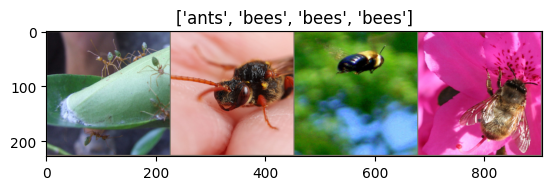

In [32]:
def imshow(inp, title=None):
    """Imshow for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)  # pause a bit so that plots are updated


# Get a batch of training data
inputs, classes = next(iter(dataloaders['train']))

# Make a grid from batch
out = torchvision.utils.make_grid(inputs)

imshow(out, title=[class_names[x] for x in classes])

Train the model

In [33]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=25):
    since = time.time()

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    for epoch in range(num_epochs):
        print(f'Epoch {epoch}/{num_epochs - 1}')
        print('-' * 10)

        # Each epoch has a training and validation phase
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()  # Set model to training mode
            else:
                model.eval()   # Set model to evaluate mode

            running_loss = 0.0
            running_corrects = 0

            # Iterate over data.
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                # zero the parameter gradients
                optimizer.zero_grad()

                # forward
                # track history if only in train
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    # backward + optimize only if in training phase
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                # statistics
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
            if phase == 'train':
                scheduler.step()

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            # deep copy the model
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

        print()

    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best val Acc: {best_acc:4f}')

    # load best model weights
    model.load_state_dict(best_model_wts)
    return model


Visualizing the model prediction

In [34]:
def visualize_model(model, num_images=6):
    was_training = model.training
    model.eval()
    images_so_far = 0
    fig = plt.figure()

    with torch.no_grad():
        for i, (inputs, labels) in enumerate(dataloaders['val']):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for j in range(inputs.size()[0]):
                images_so_far += 1
                ax = plt.subplot(num_images//2, 2, images_so_far)
                ax.axis('off')
                ax.set_title(f'predicted: {class_names[preds[j]]}')
                imshow(inputs.cpu().data[j])

                if images_so_far == num_images:
                    model.train(mode=was_training)
                    return
        model.train(mode=was_training)

### Fine-tuning the model

Load a pretrained model and reset final fully connected layer.

In [35]:
model_ft = models.resnet18(pretrained=True)
print(model_ft)
# summary(model_ft.to(device),(3,224,224))

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 173MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [36]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model_ft = models.resnet18(pretrained=True)
num_ftrs = model_ft.fc.in_features
# Here the size of each output sample is set to 2.
# Alternatively, it can be generalized to nn.Linear(num_ftrs, len(class_names)).
model_ft.fc = nn.Linear(num_ftrs, 2)

model_ft = model_ft.to(device)

criterion = nn.CrossEntropyLoss()

# Observe that all parameters are being optimized
optimizer_ft = optim.SGD(model_ft.parameters(), lr=0.001, momentum=0.9)

# Decay LR by a factor of 0.1 every 7 epochs
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)


Train and evaluate the model


Epoch 0/24
----------
train Loss: 0.5082 Acc: 0.7623
val Loss: 0.2292 Acc: 0.9346

Epoch 1/24
----------
train Loss: 0.7898 Acc: 0.7008
val Loss: 0.3001 Acc: 0.9150

Epoch 2/24
----------
train Loss: 0.6102 Acc: 0.7664
val Loss: 0.5602 Acc: 0.8301

Epoch 3/24
----------
train Loss: 0.5997 Acc: 0.8033
val Loss: 0.2451 Acc: 0.9150

Epoch 4/24
----------
train Loss: 0.5187 Acc: 0.8074
val Loss: 0.2260 Acc: 0.9281

Epoch 5/24
----------
train Loss: 0.5273 Acc: 0.7951
val Loss: 0.3326 Acc: 0.8889

Epoch 6/24
----------
train Loss: 0.4585 Acc: 0.8320
val Loss: 0.6111 Acc: 0.8301

Epoch 7/24
----------
train Loss: 0.4402 Acc: 0.8197
val Loss: 0.2757 Acc: 0.9150

Epoch 8/24
----------
train Loss: 0.3356 Acc: 0.8689
val Loss: 0.2801 Acc: 0.9020

Epoch 9/24
----------
train Loss: 0.3448 Acc: 0.8443
val Loss: 0.2500 Acc: 0.9216

Epoch 10/24
----------
train Loss: 0.3519 Acc: 0.8607
val Loss: 0.2084 Acc: 0.9346

Epoch 11/24
----------
train Loss: 0.3159 Acc: 0.8525
val Loss: 0.2221 Acc: 0.9150

Ep

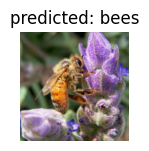

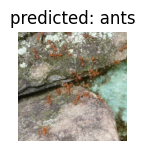

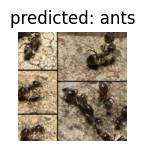

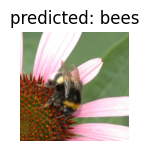

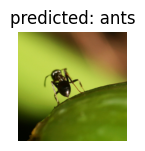

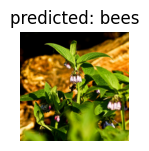

In [37]:
model_ft = train_model(model_ft, criterion, optimizer_ft, exp_lr_scheduler,
                       num_epochs=25)

visualize_model(model_ft)

In [38]:
print(3*3*64*64)
print(1*1*64*32+3*3*32*32+1*1*32*64)

36864
13312


v2 - Freezing layers in the pretrained model

Epoch 0/24
----------
train Loss: 0.5026 Acc: 0.7500
val Loss: 0.2242 Acc: 0.9085

Epoch 1/24
----------
train Loss: 0.4927 Acc: 0.7746
val Loss: 0.2102 Acc: 0.9542

Epoch 2/24
----------
train Loss: 0.4491 Acc: 0.7910
val Loss: 0.3934 Acc: 0.8366

Epoch 3/24
----------
train Loss: 0.4042 Acc: 0.7951
val Loss: 0.2350 Acc: 0.9085

Epoch 4/24
----------
train Loss: 0.5395 Acc: 0.7705
val Loss: 0.1939 Acc: 0.9412

Epoch 5/24
----------
train Loss: 0.4370 Acc: 0.7951
val Loss: 0.3746 Acc: 0.8627

Epoch 6/24
----------
train Loss: 0.5693 Acc: 0.7787
val Loss: 0.2136 Acc: 0.9150

Epoch 7/24
----------
train Loss: 0.3595 Acc: 0.8402
val Loss: 0.2220 Acc: 0.9281

Epoch 8/24
----------
train Loss: 0.3628 Acc: 0.8279
val Loss: 0.1763 Acc: 0.9608

Epoch 9/24
----------
train Loss: 0.3694 Acc: 0.8525
val Loss: 0.1777 Acc: 0.9542

Epoch 10/24
----------
train Loss: 0.3927 Acc: 0.8238
val Loss: 0.1744 Acc: 0.9477

Epoch 11/24
----------
train Loss: 0.3568 Acc: 0.8361
val Loss: 0.1604 Acc: 0.9608

Ep

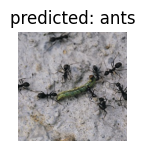

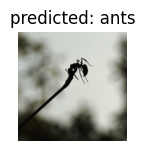

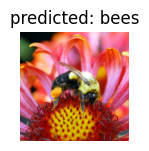

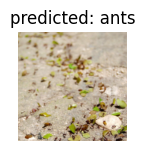

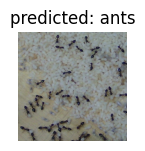

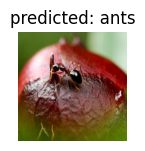

In [39]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model_ft = models.resnet18(pretrained=True)
for param in model_ft.parameters():
  param.requires_grad = False


num_ftrs = model_ft.fc.in_features
# Here the size of each output sample is set to 2.
# Alternatively, it can be generalized to nn.Linear(num_ftrs, len(class_names)).
model_ft.fc = nn.Linear(num_ftrs, 2)

model_ft = model_ft.to(device)

criterion = nn.CrossEntropyLoss()

# Observe that all parameters are being optimized
optimizer_ft = optim.SGD(model_ft.parameters(), lr=0.001, momentum=0.9)

# Decay LR by a factor of 0.1 every 7 epochs
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)


model_ft = train_model(model_ft, criterion, optimizer_ft, exp_lr_scheduler,
                       num_epochs=25)

visualize_model(model_ft)

In [40]:
print((3*3*3+1)*64)
print((64*3*3+1)*64)
print((2*2*128+1)*64)

1792
36928
32832
